# Explore here

## Primero importaré pandas y extraeré el archivo CSV y como vamos a trabjara una ARIMA importamos PMDARIMA

In [35]:
import pandas as pd

df = pd.read_csv('../data/raw/acea-water-prediction/Aquifer_Auser.csv')

df

,Date,Rainfall_Gallicano,Rainfall_Pontetetto,Rainfall_Monte_Serra,Rainfall_Orentano,Rainfall_Borgo_a_Mozzano,Rainfall_Piaggione,Rainfall_Calavorno,Rainfall_Croce_Arcana,Rainfall_Tereglio_Coreglia_Antelminelli,...,Temperature_Monte_Serra,Temperature_Ponte_a_Moriano,Temperature_Lucca_Orto_Botanico,Volume_POL,Volume_CC1,Volume_CC2,Volume_CSA,Volume_CSAL,Hydrometry_Monte_S_Quirico,Hydrometry_Piaggione
0,05/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,06/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.00,0.0,10.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,07/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.20,0.0,10.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,08/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,13.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09/03/1998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.40,0.0,12.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8149,26/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.75,0.0,23.75,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.20,-1.03
8150,27/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.35,0.0,24.30,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.21,-1.03
8151,28/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.75,0.0,24.55,-6829.936207,-7455.505,-8724.261667,-5809.63,-3000.1,0.23,-1.03
8152,29/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.90,0.0,23.60,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.23,-1.02


## Procederemos a eliminar datos nulos

In [36]:
df = df.dropna().reset_index(drop=True)

## Con esto eliminamos aproximadamente 6,ooo datos los cuales no tenían medición y seleccionamos nuestra columna objetivo, para la medición y dejarla como una serie de tiempo

In [37]:
df.columns

Index(['Date', 'Rainfall_Gallicano', 'Rainfall_Pontetetto',
       'Rainfall_Monte_Serra', 'Rainfall_Orentano', 'Rainfall_Borgo_a_Mozzano',
       'Rainfall_Piaggione', 'Rainfall_Calavorno', 'Rainfall_Croce_Arcana',
       'Rainfall_Tereglio_Coreglia_Antelminelli',
       'Rainfall_Fabbriche_di_Vallico', 'Depth_to_Groundwater_LT2',
       'Depth_to_Groundwater_SAL', 'Depth_to_Groundwater_PAG',
       'Depth_to_Groundwater_CoS', 'Depth_to_Groundwater_DIEC',
       'Temperature_Orentano', 'Temperature_Monte_Serra',
       'Temperature_Ponte_a_Moriano', 'Temperature_Lucca_Orto_Botanico',
       'Volume_POL', 'Volume_CC1', 'Volume_CC2', 'Volume_CSA', 'Volume_CSAL',
       'Hydrometry_Monte_S_Quirico', 'Hydrometry_Piaggione'],
      dtype='str')

In [38]:
ts = df[['Date','Depth_to_Groundwater_LT2']]
ts.index = ts.Date
ts

,Date,Depth_to_Groundwater_LT2
Date,,
17/05/2011,17/05/2011,-12.97
18/05/2011,18/05/2011,-12.93
19/05/2011,19/05/2011,-12.92
20/05/2011,20/05/2011,-12.93
21/05/2011,21/05/2011,-12.92
...,...,...
26/06/2020,26/06/2020,-12.36
27/06/2020,27/06/2020,-12.36
28/06/2020,28/06/2020,-12.37


In [39]:
ts.drop(['Date'], axis=1, inplace=True)

ts

,Depth_to_Groundwater_LT2
Date,
17/05/2011,-12.97
18/05/2011,-12.93
19/05/2011,-12.92
20/05/2011,-12.93
21/05/2011,-12.92
...,...
26/06/2020,-12.36
27/06/2020,-12.36
28/06/2020,-12.37


In [40]:
ts.dropna()

,Depth_to_Groundwater_LT2
Date,
17/05/2011,-12.97
18/05/2011,-12.93
19/05/2011,-12.92
20/05/2011,-12.93
21/05/2011,-12.92
...,...
26/06/2020,-12.36
27/06/2020,-12.36
28/06/2020,-12.37


## Ahora procedemos a graficar nuestra columna objetivo o seleccionada

<Axes: xlabel='Date', ylabel='Depth_to_Groundwater_LT2'>

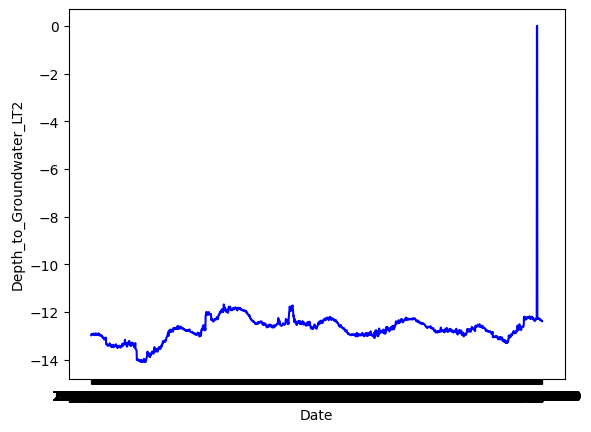

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x=df['Date'], y=df['Depth_to_Groundwater_LT2'], color='blue')

In [42]:
ts = ts[ts['Depth_to_Groundwater_LT2']<-8]

ts

,Depth_to_Groundwater_LT2
Date,
17/05/2011,-12.97
18/05/2011,-12.93
19/05/2011,-12.92
20/05/2011,-12.93
21/05/2011,-12.92
...,...
26/06/2020,-12.36
27/06/2020,-12.36
28/06/2020,-12.37


## Continuamos filtrando valores externos para quedarme con datos relevantes para mi modelo y eliminar los datos poco útiles, por lo tanto a partir del gráfico se decide filtrar los datos donde la profundidad del agua subterránea (Depth_to_Groundwater_LT2) es menor a 8 y ahora sólo tengo 2084 filas

## Procedo a descomponer la serie temporal en sus componentes principales, para obtener la tendencia, estacionalidad y el residuo

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

descomposicion = seasonal_decompose(ts, period=30)

## Y nuevamente procedemos a graficar para analizar la tendencia

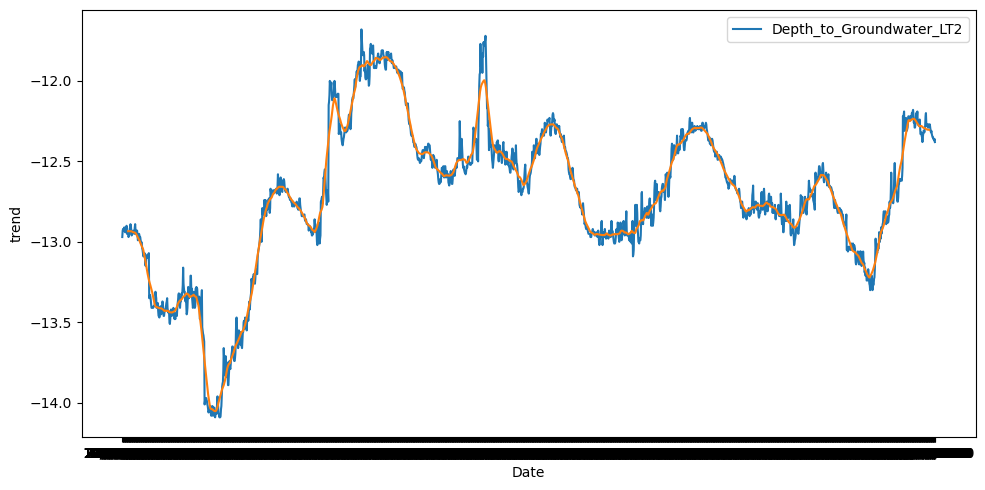

In [44]:
trend = descomposicion.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

## No exiete una tendencia o un patrón constante que se repita durante este gráfico y ahora graficaremos para obtener la estacionalidad

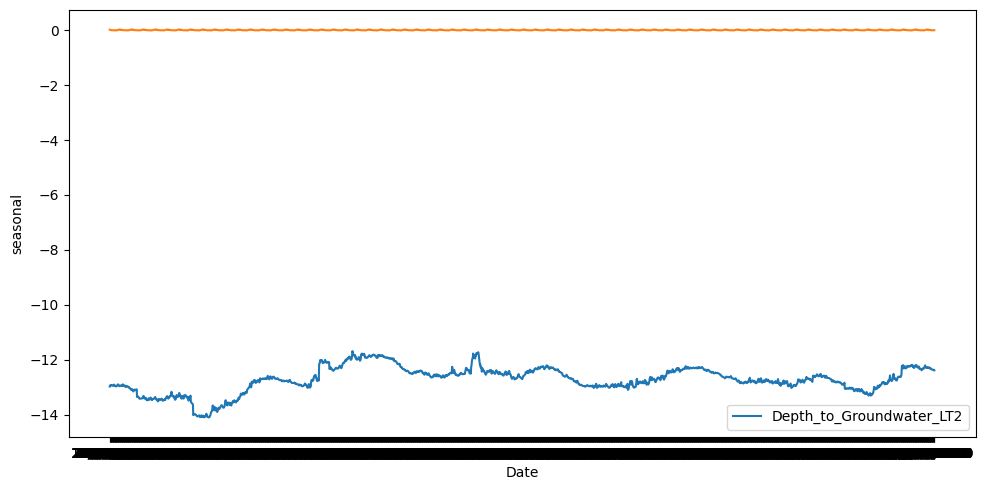

In [45]:
seasonal = descomposicion.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

## Con este gráfico podemos corroborar que en el gráfico de la tendencia hay una estacionalidad casi nula o cercana a cero, ya que no existe un patrón que se repita constantemente, y procedemos a corroborar los residuos.

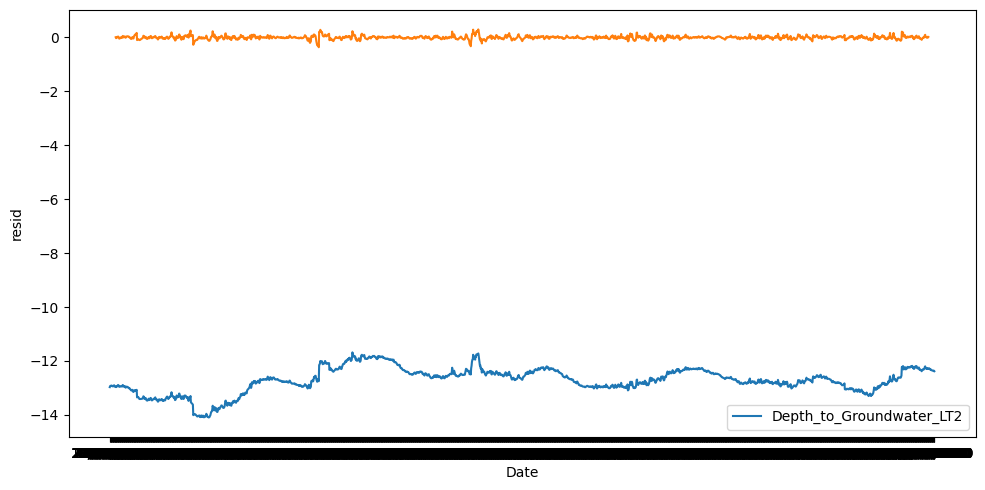

In [46]:
residuos = descomposicion.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residuos)

plt.tight_layout()

plt.show()

## A partir de este análisis se podría proceder a hacer un ARIMA, para modelar la evolución de la tendencia a corto plazo y realizar pronósticos ya que los residuos son prácticamente nulos también ya que todo indica que es estacionaria; sin embargo, se puede hacer también un análisis de autocorrelación para medir la relación entre los valores actuales y pasados, que nos permitan identificar si hay algún otro patrón que no estamos viendo y mejorar así el pronóstico del modelo.

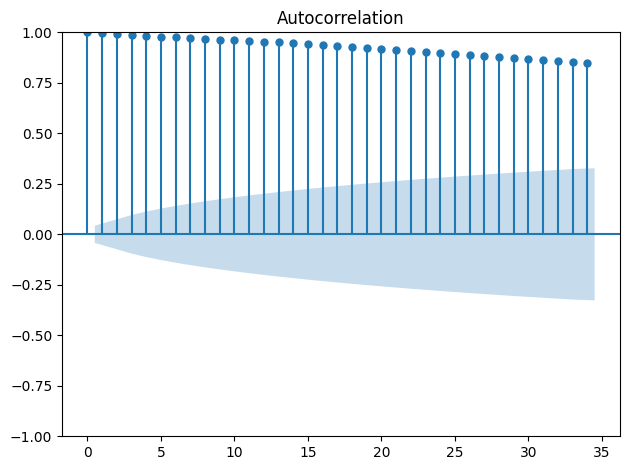

In [47]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(ts)

plt.tight_layout()

plt.show()

## Confirmamos que los datos obtenidos están muy relacionados con los ya estudiados, por lo que realizaremos un AUTO ARIMA para automatizar la selección, ajuste y pronóstico del modelo y encontrar el mejor parámetro para entrenarlo.

In [48]:
from pmdarima import auto_arima

model = auto_arima(ts, seasonal = False, trace = True, m = 30)

/home/vscode/.local/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (30) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-7334.407, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-7291.437, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-7305.095, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-7309.730, Time=0.49 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-7293.342, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-7336.396, Time=0.54 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-7333.573, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-7321.723, Time=0.77 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=-7334.347, Time=0.72 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=-7335.183, Time=0.60 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-7335.293, Time=0.18 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=-7332.521, Time=1.03 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=-7338.273, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=-7335.472, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0

In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2084
Model:               SARIMAX(1, 1, 2)   Log Likelihood                3673.137
Date:                Tue, 17 Mar 2026   AIC                          -7338.273
Time:                        07:14:33   BIC                          -7315.707
Sample:                             0   HQIC                         -7330.004
                               - 2084                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3869      0.117      3.296      0.001       0.157       0.617
ma.L1         -0.2940      0.113     -2.595      0.009      -0.516      -0.072
ma.L2         -0.1510      0.017     -8.883      0.000      -0.184      -0.118
sigma2         0.0017   1.38e-05    124.914      0.000       0.002       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             87006.27
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                             1.22
Prob(H) (two-sided):                  0.00   Kurtosis:                        34.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## El mejor modelo después del AUTO ARIMA es el (1,1,2) y procedemos a hacer la predicción de los 30 días que elegimos

In [50]:
forecast = model.predict(30)
forecast

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


2084   -12.382679
2085   -12.380305
2086   -12.379387
2087   -12.379032
2088   -12.378895
2089   -12.378841
2090   -12.378821
2091   -12.378813
2092   -12.378810
2093   -12.378809
2094   -12.378808
2095   -12.378808
2096   -12.378808
2097   -12.378808
2098   -12.378808
2099   -12.378808
2100   -12.378808
2101   -12.378808
2102   -12.378808
2103   -12.378808
2104   -12.378808
2105   -12.378808
2106   -12.378808
2107   -12.378808
2108   -12.378808
2109   -12.378808
2110   -12.378808
2111   -12.378808
2112   -12.378808
2113   -12.378808
dtype: float64

## Existe muy poca variación, manteniéndose entre 12.38 y 12.37

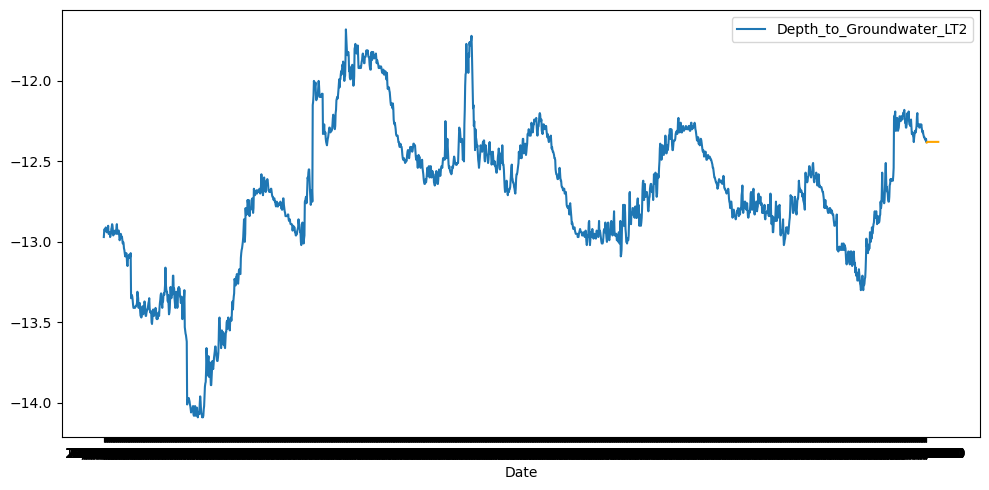

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 348, in dispatch_control
    await self.process_control(msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 354, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.

In [52]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = forecast, c = "orange")

plt.tight_layout()

plt.show()

## Conclusión: Podemos decir que la predicción es prácticamente plana (línea naranja), lo que el ARIMA nos dice que esta no se moverá o tendrá cambios poco significativos durante el siguiente mes, al ser una gran cantidad de datos la tendencia oscila y las medias se preservan en este caso. 